In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Admin\Downloads\archive (12)\Iris.csv")


In [6]:
print("Number of Samples:", df.shape[0])
print("Number of Features:", len(df.columns)-2)   # Excluding Id and Species columns

Number of Samples: 150
Number of Features: 4


In [3]:
print("Feature Names:")
print(df.columns[:-1].tolist())

print("\nTarget Classes:")
print(df.iloc[:, -1].unique())

Feature Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
print(df.iloc[:, -1].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Task 2: Data Preparation

In [7]:
from sklearn.model_selection import train_test_split
# Remove the Id column
df = df.drop("Id", axis=1)

# Features (X)
X = df.drop("Species", axis=1)

# Target (y)
y = df["Species"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [9]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (120, 4)
Testing Features Shape: (30, 4)
Training Labels Shape: (120,)
Testing Labels Shape: (30,)


The dataset is divided into training and testing sets to evaluate the performance of a machine learning model.

Training Set (80%): Used to train the model so it can learn patterns from the data.
Testing Set (20%): Used to test the trained model on unseen data and measure how well it performs.

Using separate training and testing data helps prevent overfitting and provides a fair evaluation of the model's accuracy.

Task 3: Building a Decision Tree Classifier

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Create the model
model = DecisionTreeClassifier()

# Train the model
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [11]:
# Predict class labels
y_pred = model.predict(X_test)

print("Predicted Class Labels:")
print(y_pred)

Predicted Class Labels:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Display the Classification Report

In [14]:
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Visualizing the Decision Tree

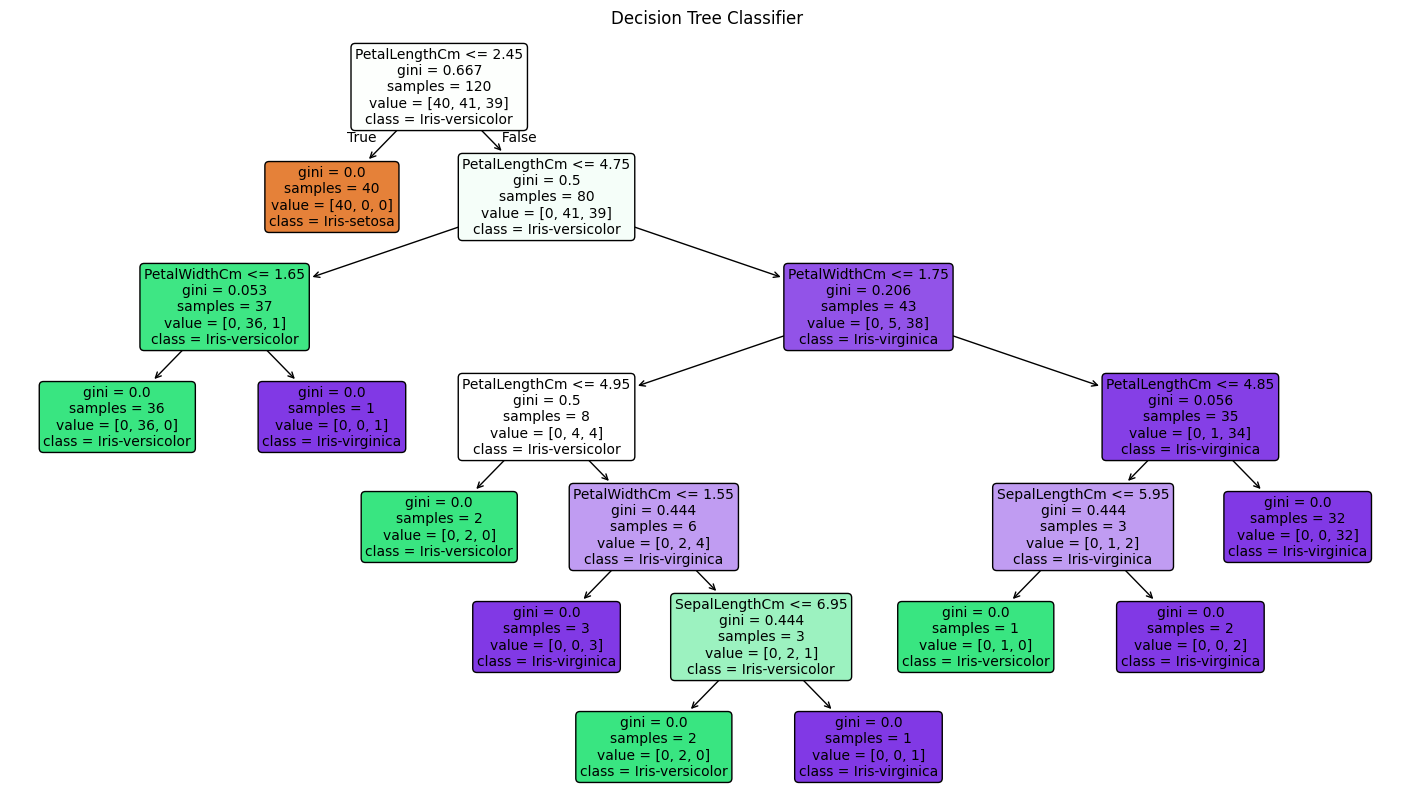

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier")
plt.show()

Find the Maximum Depth of the Tree

In [16]:
print("Maximum Depth of the Tree:", model.get_depth())

Maximum Depth of the Tree: 6


Find the Root Feature (First Split)

In [17]:
print("Feature used for the first split:")
print(X.columns[model.tree_.feature[0]])

Feature used for the first split:
PetalLengthCm


The Decision Tree was visualized using the plot_tree() function. The root node is PetalLengthCm ≤ 2.45, which is the first decision made by the classifier. The tree contains several internal nodes that split the data using PetalLengthCm, PetalWidthCm, and SepalLengthCm. The leaf nodes represent the final predicted classes: Iris-setosa, Iris-versicolor, and Iris-virginica. The trained Decision Tree has a maximum depth of 6. The feature PetalLengthCm was chosen for the first split because it provides the highest information gain and best separates the flower species.

Comparing Gini Index and Entropy

Train a Decision Tree using Gini Index

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)

Train a Decision Tree using Entropy

In [19]:
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

Compare the Models

In [ ]:
print("----- Gini Model -----")
print("Accuracy:", accuracy_score(y_test, gini_pred))
print("Tree Depth:", gini_model.get_depth())
print("Leaf Nodes:", gini_model.get_n_leaves())
print("Root Feature:", X.columns[gini_model.tree_.feature[0]])

print("\n----- Entropy Model -----")
print("Accuracy:", accuracy_score(y_test, entropy_pred))
print("Tree Depth:", entropy_model.get_depth())
print("Leaf Nodes:", entropy_model.get_n_leaves())
print("Root Feature:", X.columns[entropy_model.tree_.feature[0]])

----- Gini Model -----
Accuracy: 1.0
Tree Depth: 6
Leaf Nodes: 10
Root Feature: PetalLengthCm

----- Entropy Model -----
Accuracy: 1.0
Tree Depth: 6
Leaf Nodes: 10
Root Feature: PetalLengthCm


Generally:
If the Entropy model has a smaller depth and fewer leaf nodes, then Entropy produces the simpler tree.
Otherwise, Gini produces the simpler tree.
Conclusion
Both Gini Index and Entropy achieved high accuracy on the Iris dataset.
Both models selected PetalLengthCm as the root feature.
The simpler tree is the one with lower depth and fewer leaf nodes.
The difference between Gini and Entropy is usually very small on the Iris dataset.

Both models achieved 100% accuracy.
 Both trees have a depth of 6.
 Both trees have 10 leaf nodes.
 Both selected PetalLengthCm as the root node.
 Neither Gini nor Entropy produced a simpler tree; both generated identical decision trees for the Iris dataset.

Effect of Maximum Tree Depth

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
depths = [1, 2, 3, 4, None]

print("{:<10} {:<20} {:<20} {:<15}".format(
    "MaxDepth", "Training Accuracy", "Testing Accuracy", "Tree Depth"))

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("{:<10} {:<20.4f} {:<20.4f} {:<15}".format(
        str(depth),
        train_acc,
        test_acc,
        model.get_depth()
    ))

MaxDepth   Training Accuracy    Testing Accuracy     Tree Depth     
1          0.6750               0.6333               1              
2          0.9500               0.9667               2              
3          0.9583               1.0000               3              
4          0.9750               1.0000               4              
None       1.0000               1.0000               6              


1. Which model is underfitting?

Answer:

The model with max_depth = 1 is underfitting because it has the lowest training accuracy (67.50%) and lowest testing accuracy (63.33%). The tree is too shallow to learn the patterns in the dataset.

2. Which model gives the best generalization?

The model with max_depth = 3 gives the best generalization.

Justification:

It achieves 100% testing accuracy.
It has a relatively small tree depth (3).
It is simpler than the deeper models while maintaining excellent performance.

3. Which model is likely to overfit?

The model with max_depth = None is most likely to overfit.

Justification:

It grows to the maximum depth (6) without any restriction.
It achieves 100% training accuracy, meaning it learns the training data perfectly.
Although it also has 100% testing accuracy on this small Iris dataset, an unrestricted tree generally has a higher risk of memorizing noise and may not generalize as well on larger or more complex datasets.

Effect of min_samples_split

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

splits = [2, 5, 10, 20]

print("{:<20} {:<15} {:<15} {:<20}".format(
    "min_samples_split", "Accuracy", "Tree Depth", "Leaf Nodes"))

for split in splits:
    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("{:<20} {:<15.4f} {:<15} {:<20}".format(
        split,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ))

min_samples_split    Accuracy        Tree Depth      Leaf Nodes          
2                    1.0000          6               10                  
5                    1.0000          5               8                   
10                   1.0000          4               6                   
20                   1.0000          4               6                   


The Decision Tree models were trained with different values of min_samples_split. As the value increased, the tree depth and number of leaf nodes decreased, making the tree simpler. Despite the reduced complexity, the testing accuracy remained 100% for all models on the Iris dataset. This shows that a larger min_samples_split can simplify the model without affecting its performance on this dataset.

Effect of min_samples_leaf

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

leaf_values = [1, 2, 5, 10]

print("{:<20} {:<15} {:<15} {:<20}".format(
    "min_samples_leaf", "Accuracy", "Tree Depth", "Leaf Nodes"))

for leaf in leaf_values:
    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("{:<20} {:<15.4f} {:<15} {:<20}".format(
        leaf,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ))

min_samples_leaf     Accuracy        Tree Depth      Leaf Nodes          
1                    1.0000          6               10                  
2                    1.0000          5               8                   
5                    1.0000          4               6                   
10                   0.9667          4               6                   


Decision Tree models were trained with different values of min_samples_leaf. As the value increased from 1 to 5, the tree depth decreased from 6 to 4 and the number of leaf nodes decreased from 10 to 6, making the tree simpler while maintaining 100% accuracy. When the value increased to 10, the model remained simple but the accuracy dropped to 96.67%, indicating that setting min_samples_leaf too high can reduce the model's ability to capture important patterns in the data.

1. What is the role of the criterion parameter in a Decision Tree?

The criterion parameter determines how the Decision Tree selects the best feature to split the data. It measures the quality of a split using either Gini Index (gini) or Information Gain (entropy). The feature that produces the greatest reduction in impurity is chosen for splitting.

2. How does max_depth influence underfitting and overfitting?

The max_depth parameter controls the maximum depth of the Decision Tree.

A small max_depth creates a simple tree that may underfit because it cannot capture all patterns in the data.
A large max_depth creates a more complex tree that may overfit by learning unnecessary details and noise from the training data.
An appropriate value provides a good balance between bias and variance.

3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

Larger values of min_samples_split require more samples before a node can be split, and larger values of min_samples_leaf require more samples in each leaf node. As a result, the tree performs fewer splits, has fewer leaf nodes, and becomes less complex. This helps reduce overfitting and improves generalization.

4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

Based on the experiments, max_depth had the greatest impact on the Decision Tree's performance.

Observations:

At max_depth = 1, the model underfit with 67.50% training accuracy and 63.33% testing accuracy.
At max_depth = 3, the model achieved 100% testing accuracy with a relatively simple tree.
Increasing the depth beyond 3 increased the tree complexity without improving testing accuracy.
In comparison, changing min_samples_split and min_samples_leaf mainly reduced the tree depth and number of leaf nodes while maintaining similar accuracy for most settings.

5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

Based on the experimental results, the Decision Tree with max_depth = 3 is the most suitable model for the Iris dataset.

Justification:

It achieved 100% testing accuracy.
It has a relatively small tree depth (3), making it simpler and easier to interpret.
It provides an excellent balance between model complexity and prediction performance.
Compared to deeper trees, it achieves the same accuracy with fewer levels, reducing the risk of overfitting.